## Import

In [12]:
import pandas as pd
from urllib.parse import urlparse
from Bio import SeqIO
from Bio import AlignIO
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import json

## functions

In [2]:
def VIZ(mapping, windows, yname, xname, svgname="name", save=False):
    THUs1 = [1,142]
    THUs2 = [143,344]
    THUs3 = [345,541]
    THUs4 = [542,700]
    THUs5 = [701,948]
    THUs6 = [949,1116]
    THUs7 = [1117,1304]

    colors_7 = px.colors.qualitative.Plotly[:7]
    
    regions = [
        ("THUs1",   THUs1, colors_7[0]),
        ("THUs2",   THUs2, colors_7[1]),
        ("THUs3",   THUs3, colors_7[2]),
        ("THUs4",   THUs4, colors_7[3]),
        ("THUs5",   THUs5, colors_7[4]),
        ("THUs6",   THUs6, colors_7[5]),
        ("THUs7",   THUs7, colors_7[6])
        ]
    x = np.arange(0, 1305)
    colors = []
    
    for i in x:
        if i<=142:
            colors.append(colors_7[0])
        if 142<i<=344:
            colors.append(colors_7[1])
        if 344<i<=541:
            colors.append(colors_7[2])
        if 541<i<=700:
            colors.append(colors_7[3])
        if 700<i<=948:
            colors.append(colors_7[4])
        if 948<i<=1116:
            colors.append(colors_7[5])
        if 1116<i<=1304:
            colors.append(colors_7[6])

        
    y = list(mapping.values())
    y_arr = np.array(y)
    
    print("len(colors), len(y_arr), len(x)", len(colors), len(y_arr), len(x))

    vz_df = pd.DataFrame({
        'x': x,
        'y_arr': y_arr,
        'color': colors
        })

    # regression
    from sklearn.tree import DecisionTreeRegressor
    from sklearn.ensemble import AdaBoostRegressor
    regr = AdaBoostRegressor(
        DecisionTreeRegressor(max_depth=4), n_estimators=300, random_state=42
    )
    regr.fit(x.reshape(-1, 1), y_arr)
    y_fit = regr.predict(x.reshape(-1, 1))
    fit_df = pd.DataFrame({
        'x': x,
        'y_fit': y_fit,
        'color': colors
    })
    window_size = windows  # Adjust the window size as needed
    y_smooth = np.convolve(y_arr, np.ones(window_size)/window_size, mode='valid')

    figBar = px.bar(vz_df, y='y_arr', x='x',  color="color", color_discrete_map="identity")
    figBar.update_layout(
        xaxis_title=xname,
        yaxis_title=yname,
        bargap=0,
        bargroupgap=0,
        width=1200,
        height=300,
        paper_bgcolor="rgba(0,0,0,0)",
        plot_bgcolor="rgba(0,0,0,0)",
        margin=dict(l=20, r=20, t=0, b=0),
        showlegend=True
    )
    figBar.add_trace(
        go.Scatter(
            x=vz_df['x'][window_size-1:],  # Align x-axis to the smoothed data (to match length)
            y=y_smooth,
            mode='lines',
            name='Smoothed Trend',
            line=dict(color='black', width=0.7),
            showlegend=False
        )
    )
    for region_name, start_end, color in regions:
        figBar.add_trace(
            go.Scatter(
                x=start_end,  # Position the region on the x-axis
                y=[max(vz_df['y_arr'])] * 2,  # Use max y to position the legend
                mode='lines',
                line=dict(color=color, width=10),
                name=region_name
            )
        )
    figBar.add_vline(x=143, line_width=2, line_dash="dash", line_color="black")
    figBar.add_vline(x=345, line_width=2, line_dash="dash", line_color="black")
    figBar.add_vline(x=542, line_width=2, line_dash="dash", line_color="black")
    figBar.add_vline(x=701, line_width=2, line_dash="dash", line_color="black")
    figBar.add_vline(x=949, line_width=2, line_dash="dash", line_color="black")
    figBar.add_vline(x=1117, line_width=2, line_dash="dash", line_color="black")

    # Update layout to add the legend at the bottom
    figBar.update_layout(
        xaxis_title=xname,
        yaxis_title=yname,
        xaxis_title_font=dict(size=11),
        yaxis_title_font=dict(size=11),
        bargap=0,
        bargroupgap=0,
        width=1100,
        height=300,
        paper_bgcolor="rgba(0,0,0,0)",
        plot_bgcolor="rgba(0,0,0,0)",
        margin=dict(l=20, r=20, t=0, b=100),  # Increased bottom margin to fit the legend
        showlegend=True,
        legend=dict(
            orientation='h',  # Horizontal legend at the bottom
            x=0,              # Align the legend to the left
            y=-0.5,           # Place the legend below the plot
            xanchor='left',
            yanchor='top',
            font=dict(size=10)
        )
    )
    # figBar.update_xaxes(
    #     tickmode="array",
    #     tickvals=[500, 1000, 1304, 1500, 2000, 2156, 2210, 2428, 2500],              # only one tick
    #     ticktext=["500", "1000", "<b>1305</b>", "1500", "2000", "<b>2156</b>", "<b>2210</b>", "<b>2428</b>", "2500"],     # bold number (HTML works)
    #     tickfont=dict(
    #         color="black",
    #         size=10
    #     ),
    #     showline=True,
    #     linecolor="black",
    #     linewidth=1,
    #     ticks="outside"
    # )

    if save:
        figBar.write_image(svgname)
        #figBar.write_html(svgname)
    figBar.show()

In [4]:
def parse_cif(cif_fp, data_jsonfp):
    idx_lst = []
    resid_lst = []
    res_lst = []
    plddt_lst = []
    confi_lst = []
    
    with open(data_jsonfp, "r", encoding="utf-8") as f:
        data = json.load(f)
    pLDDT_pool = data["atom_plddts"]
    
    with open(cif_fp) as f:
        for line in f:
            if line.startswith("ATOM"):
                fields = line.split()
                atom_id = fields[1]
                atom_name = fields[3]
                resname = fields[5]
                chain = fields[6]
                res_id = fields[8]
                x, y, z = fields[10:13]
                idx_lst.append(int(atom_id)-1)
                resid_lst.append(int(res_id))
                res_lst.append(resname)
                plddt_lst.append(pLDDT_pool[int(atom_id)-1])
                
    df = pd.DataFrame({
            "atom_idx": idx_lst,
            "resid": resid_lst,
            "res_name": res_lst,
            "plddt": plddt_lst
        })

    avg_df = df.groupby(["resid", "res_name"], as_index=False).agg(avg_plddt=("plddt", "mean"))
    for i in avg_df["avg_plddt"].tolist():
        if i >=90:
            confi_lst.append("Very high")
        elif 90>i>=70:
            confi_lst.append("High")
        elif 70>i>=50:
            confi_lst.append("Low")
        else:
            confi_lst.append("Very low")
    avg_df["confi"] = confi_lst

    return avg_df
    
def parse_cif2(cif_fp):
    idx_lst = []
    resid_lst = []
    res_lst = []
    plddt_lst = []
    confi_lst = []

    
    with open(cif_fp) as f:
        for line in f:
            if line.startswith("ATOM"):
                fields = line.split()
                atom_id = fields[1]
                atom_name = fields[3]
                resname = fields[5]
                chain = fields[6]
                res_id = fields[8]
                x, y, z = fields[10:13]
                plddt = fields[14]
                idx_lst.append(int(atom_id)-1)
                resid_lst.append(int(res_id))
                res_lst.append(resname)
                plddt_lst.append(float(plddt))
                
    df = pd.DataFrame({
            "atom_idx": idx_lst,
            "resid": resid_lst,
            "res_name": res_lst,
            "plddt": plddt_lst
        })

    avg_df = df.groupby(["resid", "res_name"], as_index=False).agg(avg_plddt=("plddt", "mean"))
    for i in avg_df["avg_plddt"].tolist():
        if i >=90:
            confi_lst.append("Very high")
        elif 90>i>=70:
            confi_lst.append("High")
        elif 70>i>=50:
            confi_lst.append("Low")
        else:
            confi_lst.append("Very low")
    avg_df["confi"] = confi_lst

    return avg_df


In [6]:
def parse_dali(daliTXT):
    qr_seq = ""
    tg_seq = ""
    with open(daliTXT) as f:
        for line in f:
            if line.startswith("Query"):
                fields = line.split()
                qr_seq += fields[1]
            if line.startswith("Sbjct"):
                fields = line.split()
                tg_seq += fields[1]
    return qr_seq, tg_seq

In [7]:
def gap2orig(gap):
    mapD = {}
    orig_pos = 0
    for gap_pos, ch in enumerate(gap, start=0):
        if ch != "-":
            mapD[gap_pos] = orig_pos
            orig_pos += 1
    return mapD
    
def gap2orig2(gap):
    mapD = {}
    orig_pos = 0
    for gap_pos, ch in enumerate(gap, start=0):
        if ch != ".":
            mapD[gap_pos] = orig_pos
            orig_pos += 1
    return mapD
    
def mapping(dalitxt):
    q,t = parse_dali(dalitxt)
    Q = ""
    T = ""
    for iq in q:
        if iq != "-":
            Q+=iq
    for it in t:
        if it != "-":
            T+=it
    #print(len(T), len(Q))
    Q_aa_lst = []
    Q_pos_lst = []
    T_aa_lst = []
    T_pos_lst = []
    q_pos = 0
    t_pos = 0
    Q_map = gap2orig(q)
    T_map = gap2orig(t)
    for idx, (q_ch, t_ch) in enumerate(zip(q, t), start=0):
        if q_ch != "-":
            if t_ch != "-":
                Q_aa = Q[Q_map[idx]]
                Q_aa_lst.append(Q_aa)
                Q_pos_lst.append(Q_map[idx])
                T_aa = T[T_map[idx]]
                T_aa_lst.append(T_aa)
                T_pos_lst.append(T_map[idx])
            else:
                Q_aa = Q[Q_map[idx]]
                Q_aa_lst.append(Q_aa)
                Q_pos_lst.append(Q_map[idx])
                T_aa_lst.append(None)
                T_pos_lst.append(None)

        
    df = pd.DataFrame({
            "Q_pos": Q_pos_lst,
            "Q_aa":  Q_aa_lst,
            "T_pos": T_pos_lst,
            "T_aa":  T_aa_lst,
        })
    return df

def mapping2(q,t):
    Q = ""
    T = ""
    for iq in q:
        if iq != ".":
            Q+=iq
    for it in t:
        if it != ".":
            T+=it
    
    Q_aa_lst = []
    Q_pos_lst = []
    T_aa_lst = []
    T_pos_lst = []
    q_pos = 0
    t_pos = 0
    Q_map = gap2orig2(q)
    T_map = gap2orig2(t)
    for idx, (q_ch, t_ch) in enumerate(zip(q, t), start=0):
        if t_ch != ".":
            T_aa = T[T_map[idx]]
            T_aa_lst.append(T_aa)
            T_pos_lst.append(int(T_map[idx]))
            if idx not in Q_map.keys():
                Q_aa_lst.append(None)
                Q_pos_lst.append(None)
            else:              
                Q_aa = Q[Q_map[idx]]
                Q_aa_lst.append(Q_aa)
                Q_pos_lst.append(int(Q_map[idx]))
        
    df = pd.DataFrame({
            "Q_pos": Q_pos_lst,
            "Q_aa":  Q_aa_lst,
            "T_pos": T_pos_lst,
            "T_aa":  T_aa_lst,
        })
    return df

In [8]:
def parse_hydropathy(fp):
    with open(fp) as f:
        lines = f.readlines()
    rows = []
    for i, line in enumerate(lines):
        if line.startswith("Sequence: "):
            seq = lines[i + 1]

        if line.startswith("Position:"):
            pos = int(line.split()[1])-1
            aa = seq[pos - 1] 
            score = float(line.split()[3])
            rows.append((pos, aa, score))

    df = pd.DataFrame(rows, columns=["pos", "AA", "score"])
    return df

In [9]:
def parse_3line(fp):
    with open(fp) as f:
        lines = f.readlines()
    seq = lines[1][:-1]
    IMO = lines[2][:-1]
    df = pd.DataFrame({
        "pos": list(range(len(seq))),
        "aa":  list(seq),
        "IMO": list(IMO)
    })
    return df

In [32]:
def TMstartend_dff3(fp):
    lst = []
    with open(fp) as f:
        for line in f:
            if line.startswith("Unnamed"):
                segs = line.split()
                if segs[1] == "TMhelix":
                    st = segs[2]
                    end = segs[3]
                    lst.append((int(st), int(end)))
    return lst

# analysis

### pLDDT
The predicted structure is colored by local prediction confidence (pLDDT) per amino acid location. Blue indicates confident predictions (pLDDT > 0.9), while red indicates low confidence (pLDDT < 0.5).
https://www.ebi.ac.uk/training/online/courses/alphafold/inputs-and-outputs/evaluating-alphafolds-predicted-structures-using-confidence-scores/plddt-understanding-local-confidence/

In [65]:
# MGYP000926044221
MGYPdata_jsonfp = "./fold_MGYP000926044221_fold_2025_12_28_15_59/fold_2025_12_28_15_59_full_data_0.json"
MGYPAI_cif_fp = "./fold_MGYP000926044221_fold_2025_12_28_15_59/fold_2025_12_28_15_59_model_0.cif"

MGYP_df=parse_cif(cif_fp=MGYPAI_cif_fp, data_jsonfp=MGYPdata_jsonfp)

for i in MGYP_df[MGYP_df["confi"]=="Very high"]["resid"].tolist():
    print(f"{i}+",end="") #0xFFDB13  #66CCFF #FFDB13 #FF7A3D

73+290+291+292+293+

In [74]:
# A0A482RRZ8
A0A4_df = parse_cif2("./AF-A0A482RRZ8-F1-model_v6.cif")
for i in A0A4_df[A0A4_df["confi"]=="Low"]["resid"].tolist():
    print(f"{i}+",end="") # Very low #FF7A3D # Low #FFDB13 # High #66CCFF   # Very high #1F66FF

57+147+148+149+150+151+152+153+154+155+156+182+198+230+231+232+233+234+235+236+237+238+239+240+241+242+243+244+245+246+247+248+249+250+251+252+253+254+255+256+257+258+260+261+262+264+265+266+267+268+269+270+271+272+273+274+275+276+277+278+279+290+292+293+294+295+296+297+298+299+300+301+302+303+304+305+306+307+308+309+310+311+312+313+314+315+316+317+318+319+320+321+322+323+324+325+326+327+328+329+330+331+332+333+334+335+345+346+347+348+349+350+351+352+353+354+355+356+357+358+359+361+362+363+364+365+366+367+368+369+371+372+373+375+376+377+378+379+380+381+382+383+384+385+386+387+388+389+390+391+392+393+394+395+396+397+398+399+400+401+402+403+404+405+406+407+408+468+470+471+472+473+474+475+476+477+478+479+480+481+485+487+488+489+490+491+492+493+494+495+496+497+498+500+501+502+503+504+507+508+516+519+521+522+523+524+525+526+527+528+529+530+531+532+533+558+559+560+561+562+563+564+565+566+567+568+569+570+571+572+573+574+575+576+577+578+579+580+581+582+583+584+585+586+587+589+590+591+593+594+5

### Hydropathy and DEEPTMHMM

In [200]:
# dali
# A0A48_fp = "./one2one/bladA_A0A4.txt"
# mgyp_fp = "./one2one/bladA.txt"

# A0A48_mapdf = mapping(A0A48_fp)
# mgyp_mapdf = mapping(mgyp_fp)

In [10]:
A0A4_hydro_fp = "./expasy/A0A4_scores2951418.txt"
mgyp_hydro_fp = "./expasy/mgyp_scores2956005.txt"
blade_hydro_fp = "./expasy/blade_scores1993713.txt"
A0A4_hydro_df = parse_hydropathy(A0A4_hydro_fp)
mgyp_hydro_df = parse_hydropathy(mgyp_hydro_fp)
blade_hydro_df = parse_hydropathy(blade_hydro_fp)


# # foldseek
# blade2cases_df = pd.read_csv("./blade2cases.csv")
# A0A48_mapdf2 = mapping2(q=blade2cases_df[blade2cases_df["target"]=="AF-A0A482RRZ8-F1-model_v6"]["qAln"].tolist()[0],
#                         t=blade2cases_df[blade2cases_df["target"]=="AF-A0A482RRZ8-F1-model_v6"]["dbAln"].tolist()[0])
# mgyp_mapdf2 = mapping2(q=blade2cases_df[blade2cases_df["target"]=="MGYP000926044221"]["qAln"].tolist()[0],
#                        t=blade2cases_df[blade2cases_df["target"]=="MGYP000926044221"]["dbAln"].tolist()[0])

# chimeraX
a0a4_chimeraX_map = {}
a0a4_chimeraX_fp = "./chimeraXalign/a0a4chimeraX.fasta"
mgyp_chimeraX_map = {}
mgyp_chimeraX_fp = "./chimeraXalign/mgypchimeraX.fasta"
for record in SeqIO.parse(a0a4_chimeraX_fp, "fasta"):
    a0a4_chimeraX_map[record.id] = str(record.seq)
for record in SeqIO.parse(mgyp_chimeraX_fp, "fasta"):
    mgyp_chimeraX_map[record.id] = str(record.seq)

A0A48_mapdf3 = mapping2(q=a0a4_chimeraX_map["blade1_1304.pdb,"],
                        t=a0a4_chimeraX_map["AF-A0A482RRZ8-F1-model_v6_aligned_CA.pdb,"])
mgyp_mapdf3 = mapping2(q=mgyp_chimeraX_map["blade1_1304.pdb,"],
                       t=mgyp_chimeraX_map["MGYP000926044221_aligned_CA.pdb,"])

In [11]:
hydro_blade_y = []
hydro_a0a4_y = []
hydro_mgyp_y = []
for _,row in blade_hydro_df.iterrows():
    blade_pos = row["pos"]

    hydro_blade_y.append(row["score"])
    # a0a48
    val = A0A48_mapdf3[A0A48_mapdf3["Q_pos"]==blade_pos]
    if val.empty:
        hydro_a0a4_y.append(None)
    else:
        T_pos = val["T_pos"].values[0]
        sel = A0A4_hydro_df[A0A4_hydro_df["pos"]==T_pos]
        if sel.empty:
            hydro_a0a4_y.append(None)
        else:
            hydroScore = sel["score"].values[0]
            hydro_a0a4_y.append(float(hydroScore))
        
    # mgyp
    val2 = mgyp_mapdf3[mgyp_mapdf3["Q_pos"]==blade_pos]
    if val2.empty:
        hydro_mgyp_y.append(None)
    else:
        T_pos2 = val2["T_pos"].values[0]
        sel2 = mgyp_hydro_df[mgyp_hydro_df["pos"]==T_pos2]
        if sel2.empty:
            hydro_mgyp_y.append(None)
        else:
            hydroScore2 = sel2["score"].values[0]
            hydro_mgyp_y.append(float(hydroScore2))


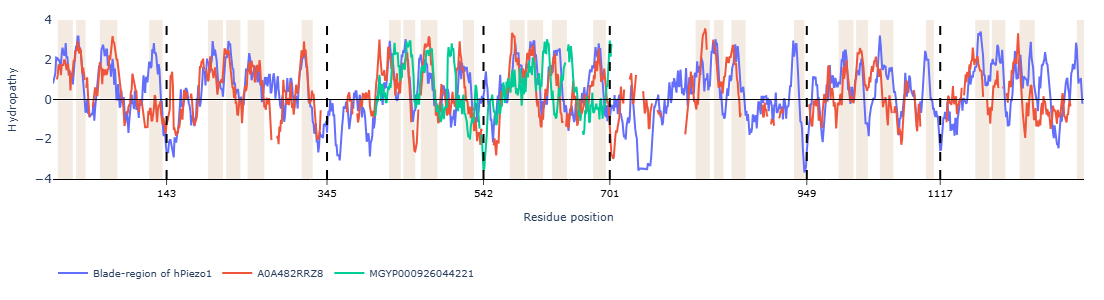

In [39]:
x = np.arange(0, len(hydro_blade_y)+1)
fighydro = go.Figure()

fighydro.add_trace(go.Scatter(
    x=x,
    y=hydro_blade_y,
    mode="lines",
    name="Blade-region of hPiezo1"
))

fighydro.add_trace(go.Scatter(
    x=x,
    y=hydro_a0a4_y,
    mode="lines",
    name="A0A482RRZ8"
))

fighydro.add_trace(go.Scatter(
    x=x,
    y=hydro_mgyp_y,
    mode="lines",
    name="MGYP000926044221"
))


fighydro.add_vline(x=143, line_width=2, line_dash="dash", line_color="black")
fighydro.add_vline(x=345, line_width=2, line_dash="dash", line_color="black")
fighydro.add_vline(x=542, line_width=2, line_dash="dash", line_color="black")
fighydro.add_vline(x=701, line_width=2, line_dash="dash", line_color="black")
fighydro.add_vline(x=949, line_width=2, line_dash="dash", line_color="black")
fighydro.add_vline(x=1117, line_width=2, line_dash="dash", line_color="black")
fighydro.add_hline(
    y=0,
    line_width=1,
    line_color="black"
)


## add tan-colored boxes
TM_st_end_lst = TMstartend_dff3("./DeepTMHMM/blade_deeptmhmm/TMRs.gff3")
for x1, x2 in TM_st_end_lst:
    fighydro.add_shape(
        type="rect",
        xref="x",
        yref="paper", 
        x0=x1,
        x1=x2,
        y0=0,
        y1=1,
        fillcolor="tan",
        opacity=0.25,
        line_width=0,
        layer="below",
        line=dict(width=0)
    )





# Update layout to add the legend at the bottom
fighydro.update_layout(
    xaxis_title="Residue position",
    yaxis_title="Hydropathy",
    xaxis_title_font=dict(size=11),
    yaxis_title_font=dict(size=11),
    width=1100,
    height=300,
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    margin=dict(l=20, r=20, t=20, b=100),  # Increased bottom margin to fit the legend
    showlegend=True,
    legend=dict(
        orientation='h',  # Horizontal legend at the bottom
        x=0,              # Align the legend to the left
        y=-0.5,           # Place the legend below the plot
        xanchor='left',
        yanchor='top',
        font=dict(size=10)
    )
)
fighydro.update_xaxes(
    tickmode="array",
    tickvals=[143, 345, 542, 701, 949, 1117],              # only one tick
    ticktext=["143", "345", "542", "701", "949", "1117"],     # bold number (HTML works)
    tickfont=dict(
        color="black",
        size=10
    ),
    showline=True,
    linecolor="black",
    linewidth=1,
    ticks="outside"
)
fighydro.update_xaxes(showgrid=False)
fighydro.update_yaxes(showgrid=False)
fighydro.update_yaxes(range=[-4, 4])
fighydro.write_image("./hydro.svg")
fighydro.show()#.write_image("./hydro.svg")

In [391]:
## deeptmhmm
A0A4_tm_fp = "./A0A48deeptmhmm/predicted_topologies.3line"
mgyp_tm_fp = "./MGYPdeeptmhmm/predicted_topologies.3line"
blade_tm_fp = "./deeptmhmm/predicted_topologies.3line"

In [400]:
A0A4_tm_df = parse_3line(A0A4_tm_fp)
mgyp_tm_df = parse_3line(mgyp_tm_fp)
blade_tm_df = parse_3line(blade_tm_fp)

In [490]:
tm_blade_y_imo = []
tm_a0a4_y_imo = []
tm_mgyp_y_imo = []
for _,row in blade_tm_df.iterrows():
    blade_pos = row["pos"]
    tm_blade_y_imo.append(row["IMO"])
    # a0a48
    val = A0A48_mapdf3[A0A48_mapdf3["Q_pos"]==blade_pos]
    if val.empty:
        tm_a0a4_y_imo.append(None)
    else:
        T_pos = val["T_pos"].values[0]
        sel = A0A4_tm_df[A0A4_tm_df["pos"]==T_pos]
        if sel.empty:
            tm_a0a4_y_imo.append(None)
        else:
            imo = sel["IMO"].values[0]
            tm_a0a4_y_imo.append(imo)
        
    # mgyp
    val2 = mgyp_mapdf3[mgyp_mapdf3["Q_pos"]==blade_pos]
    if val2.empty:
        tm_mgyp_y_imo.append(None)
    else:
        T_pos2 = val2["T_pos"].values[0]
        sel2 = mgyp_tm_df[mgyp_tm_df["pos"]==T_pos2]
        if sel2.empty:
            tm_mgyp_y_imo.append(None)
        else:
            imo = sel2["IMO"].values[0]
            tm_mgyp_y_imo.append(imo)

Empty DataFrame
Columns: [Q_pos, Q_aa, T_pos, T_aa]
Index: []
Empty DataFrame
Columns: [Q_pos, Q_aa, T_pos, T_aa]
Index: []
Empty DataFrame
Columns: [Q_pos, Q_aa, T_pos, T_aa]
Index: []
Empty DataFrame
Columns: [Q_pos, Q_aa, T_pos, T_aa]
Index: []
Empty DataFrame
Columns: [Q_pos, Q_aa, T_pos, T_aa]
Index: []
Empty DataFrame
Columns: [Q_pos, Q_aa, T_pos, T_aa]
Index: []
Empty DataFrame
Columns: [Q_pos, Q_aa, T_pos, T_aa]
Index: []
Empty DataFrame
Columns: [Q_pos, Q_aa, T_pos, T_aa]
Index: []
Empty DataFrame
Columns: [Q_pos, Q_aa, T_pos, T_aa]
Index: []
Empty DataFrame
Columns: [Q_pos, Q_aa, T_pos, T_aa]
Index: []
Empty DataFrame
Columns: [Q_pos, Q_aa, T_pos, T_aa]
Index: []
Empty DataFrame
Columns: [Q_pos, Q_aa, T_pos, T_aa]
Index: []
Empty DataFrame
Columns: [Q_pos, Q_aa, T_pos, T_aa]
Index: []
Empty DataFrame
Columns: [Q_pos, Q_aa, T_pos, T_aa]
Index: []
Empty DataFrame
Columns: [Q_pos, Q_aa, T_pos, T_aa]
Index: []
Empty DataFrame
Columns: [Q_pos, Q_aa, T_pos, T_aa]
Index: []
Empty Da

In [422]:
# I = -1, M=0, O=1
tm_blade_y = []
for a in tm_blade_y_imo:
    if a=="I":
        tm_blade_y.append(-1)
    elif a=="M":
        tm_blade_y.append(0)
    elif a=="O":
        tm_blade_y.append(1)
    else:
        tm_blade_y.append(None)
    
tm_a0a4_y = []
for b in tm_a0a4_y_imo:
    if b=="I":
        tm_a0a4_y.append(-1)
    elif b=="M":
        tm_a0a4_y.append(0)
    elif b=="O":
        tm_a0a4_y.append(1)
    else:
        tm_a0a4_y.append(None)
tm_mgyp_y = []
for c in tm_mgyp_y_imo:
    if c=="I":
        tm_mgyp_y.append(-1)
    elif c=="M":
        tm_mgyp_y.append(0)
    elif c=="O":
        tm_mgyp_y.append(1)
    else:
        tm_mgyp_y.append(None)

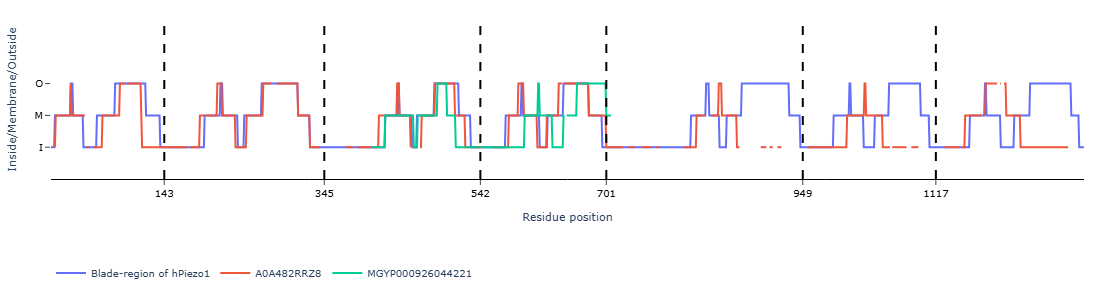

In [432]:
x = np.arange(0, len(tm_blade_y)+1)
figTM = go.Figure()

figTM.add_trace(go.Scatter(
    x=x,
    y=tm_blade_y,
    mode="lines",
    name="Blade-region of hPiezo1"
))

figTM.add_trace(go.Scatter(
    x=x,
    y=tm_a0a4_y,
    mode="lines",
    name="A0A482RRZ8"
))

figTM.add_trace(go.Scatter(
    x=x,
    y=tm_mgyp_y,
    mode="lines",
    name="MGYP000926044221"
))


figTM.add_vline(x=143, line_width=2, line_dash="dash", line_color="black")
figTM.add_vline(x=345, line_width=2, line_dash="dash", line_color="black")
figTM.add_vline(x=542, line_width=2, line_dash="dash", line_color="black")
figTM.add_vline(x=701, line_width=2, line_dash="dash", line_color="black")
figTM.add_vline(x=949, line_width=2, line_dash="dash", line_color="black")
figTM.add_vline(x=1117, line_width=2, line_dash="dash", line_color="black")
# figTM.add_hline(
#     y=0,
#     line_width=1,
#     line_color="black"
# )

# Update layout to add the legend at the bottom
figTM.update_layout(
    xaxis_title="Residue position",
    yaxis_title="Inside/Membrane/Outside",
    xaxis_title_font=dict(size=11),
    yaxis_title_font=dict(size=11),
    width=1100,
    height=300,
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    margin=dict(l=20, r=20, t=20, b=100),  # Increased bottom margin to fit the legend
    showlegend=True,
    legend=dict(
        orientation='h',  # Horizontal legend at the bottom
        x=0,              # Align the legend to the left
        y=-0.5,           # Place the legend below the plot
        xanchor='left',
        yanchor='top',
        font=dict(size=10)
    )
)
figTM.update_xaxes(
    tickmode="array",
    tickvals=[143, 345, 542, 701, 949, 1117],              # only one tick
    ticktext=["143", "345", "542", "701", "949", "1117"],     # bold number (HTML works)
    tickfont=dict(
        color="black",
        size=10
    ),
    showline=True,
    linecolor="black",
    linewidth=1,
    ticks="outside"
)

figTM.update_yaxes(
    tickmode="array",
    tickvals=[-1, 0, 1],              # only one tick
    ticktext=["I", "M", "O"],     # bold number (HTML works)
    tickfont=dict(
        color="black",
        size=10
    ),
    showline=False,
    linecolor="black",
    linewidth=1,
    ticks="outside"
)
figTM.update_yaxes(range=[-2, 3])
figTM.write_image("./TM.svg")
figTM.show()

In [491]:
blade2cases_df

,queries_header,queries_seq,mode,db,target,prob,e_val,score,qStartPos,qEndPos,qLen,dbStartPos,dbEndPos,dbLen,qAln,dbAln,tSeq,taxId,taxName,description
0,job_A blade,MEPHVLGAVLYWLLLPCALLAACLLRFSGLSLVYLLFLLLLPWFPG...,3diaa,afdb50,AF-A0A482RRZ8-F1-model_v6,1,0.000347,141,1,957,1304,1,946,1203,MEPHVLGAVLYWLLLPCALLAACLLRFSGLSLVYLLFLLLLPWFPG...,MGAGLSAAGLITASLAAALFNVSTLTSVPLFAV-LLSICMWVFSPA...,MGAGLSAAGLITASLAAALFNVSTLTSVPLFAVLLSICMWVFSPAG...,1906665.0,archaeon,Uncharacterized protein
1,job_A blade,MEPHVLGAVLYWLLLPCALLAACLLRFSGLSLVYLLFLLLLPWFPG...,3diaa,mgnify_esm30,MGYP000926044221,1,0.051400,145,558,957,1304,1,382,431,PTRTQTLLQSLGELVKGVYAKYWIYVCAGMFIVVSFAGRLVVYKIV...,PTTDYIFVELPLQVIERA----SLVVVIVIILLSSLQPP-TVMTLF...,PTTDYIFVELPLQVIERASLVVVIVIILLSSLQPPTVMTLFSLVDV...,NaN,NaN,NaN


## zoom in

In [457]:
# between 345 and 701
blade2cases_df = pd.read_csv("./blade2cases.csv")
blade_seq = blade2cases_df["queries_seq"].tolist()[0]
blade_repeat34_seq = blade_seq[345: 702]
a0a4_seq = blade2cases_df[blade2cases_df["target"]=="AF-A0A482RRZ8-F1-model_v6"]["tSeq"].tolist()[0][412:761]
mgyp_seq = blade2cases_df[blade2cases_df["target"]=="MGYP000926044221"]["tSeq"].tolist()[0]

In [458]:
blade_repeat34_seq

'KGYEARELELAELDQWPQERESDQHVVPTAPDTEADNCIVHELTGQSSVLRRPVRPKRAEPREASPLHSLGHLIMDQSYVCALIAMMVWSITYHSWLTFVLLLWACLIWTVRSRHQLAMLCSPCILLYGMTLCCLRYVWAMDLRPELPTTLGPVSLRQLGLEHTRYPCLDLGAMLLYTLTFWLLLRQFVKEKLLKWAESPAALTEVTVADTEPTRTQTLLQSLGELVKGVYAKYWIYVCAGMFIVVSFAGRLVVYKIVYMFLFLLCLTLFQVYYSLWRKLLKAFWWLVVAYTMLVLIAVYTFQFQDFPAYWRNLTGFTDEQLGDLGLEQFSVSELFSSILVPGFFLLACILQLHYFH'

In [459]:
a0a4_seq

'PTLSVTSCNSRLTPTSPPVYAPVSPNAAYISHQNSSVQLLLLGQGKLGVVVALLAKQWVLVTLALLYGLSLSHVDVVHAGYVVFFVWFATQAKHRRDYWPLLVAYCVLAICIMFMWDVTTWALPDTRANIPPWIVGPNIPNPTVDLWHSTFATNMLVFGVAVLQAPLYQAPLRDAARARMREAKESARDFRRQWQHAKFVIAHYSPRLVILICFGICLIPPITFNSVISLSLTFVLALLHLLMSQEQAGDLARHHAGRPNCRCMRSARLFATFSIVEGVILGLRYMYQFESGQEALDNTIGALFRNWMPMRDVGFWRYVDASYNGSVYLQLLDTAALMVVTAVQWHLLV'

In [460]:
mgyp_seq

'PTTDYIFVELPLQVIERASLVVVIVIILLSSLQPPTVMTLFSLVDVIGILFITALNVDNISRRYIWTRRWVSVWILIEGLCLVILYLYQFDAVAQFFYDARGLPQKCNWTISDQSVWQCTRINSTWVTFSDLGLREFESSGASRLAVAFGMFYNCVSFVALLILFISVGRKLEKHRLVSGDSFGSEADYYQLLDDEVAPMRDVAVAVGSNVRSQCAEVTHTIVVALKYFCYTHGGKMGIIAAVIICGSDVCAFQFILLLLLCALVICTGKQTVAGGGTPIFSKAWSVIFVCGAIRSVLTILFQFNSVYYHVAVPYSDDTTWAGLRVAWVSRGMKVPKLSNPERATMMQMWAAMQESIYLILIGFLMKMSLEFRPAAREFSVLWKSFRAQENISAGGEERENDGETKGEELHGSDEPTFHRRSGAFCFHFGS'

In [456]:
A0A48_mapdf3[A0A48_mapdf3["Q_pos"]==701]

,Q_pos,Q_aa,T_pos,T_aa
760,701.0,H,760,V


### sequence based alignment

In [467]:
a0a4_seq412_760_seqaln=""
blade_repeat34_seq345_701_seqaln=""
mgyp_seq_seqaln=""
with open("./zoomin/clustalo-I20260101-132651-0307-48147870-p1m.aln-clustal_num") as f:
    for line in f:
        if line.startswith("a0a4_seq412_760"):
            a0a4_seq412_760_seqaln += line.split()[1]
        if line.startswith("blade_repeat34_seq345_701"):
            blade_repeat34_seq345_701_seqaln += line.split()[1]
        if line.startswith("mgyp_seq"):
            mgyp_seq_seqaln += line.split()[1]

In [474]:
a0a4_seq412_760_seqaln[30]

'P'

In [473]:
blade_repeat34_seq345_701_seqaln[30]

'P'

In [472]:
mgyp_seq_seqaln[30]

'P'

### structure based alignment

In [ ]:
blade_repeat34_stc = 

In [ ]:
blade_repeat34_seq = blade_seq[345: 702]
a0a4_seq = blade2cases_df[blade2cases_df["target"]=="AF-A0A482RRZ8-F1-model_v6"]["tSeq"].tolist()[0][412:761]
mgyp_seq = blade2cases_df[blade2cases_df["target"]=="MGYP000926044221"]["tSeq"].tolist()[0]

In [479]:
a0a4_chimeraX_map

{'blade1_1304.pdb,': 'MEPHVLGAVLYWLLLPCALLAACLL...RFSGLSLVYLLFLLLLPWFPGPTRCGLQGHTGRLLRALLGLSLLFLVAHLALQICLHIVPRLDQLLGPSCSRWETLSRHIGV.TRLDLKD...................IPNAIRLVAPDLGILVVSSVCLGICGRL...............ARNTRQS....PH............PREL.....DDDERDVDASPTAGLQEAATLAPTRRSRLAARFRVTAHWLLVAAGRVLAVTLLALAGIAHPSALSSVYLLLFLALCTWWACHFPISTRGFSRLCVAVGCFGAGHLICLYCYQM.PLAQA...LLPPAGIWARVLGLKDFVG.....PTNCSSPHAL...............VLNTGLDWPVYASPGVLLLLCYATASLRKL......RA..YRPSGQRKEAAKGYEARELELAELDQWPQERESDQHVVPTAPDTEADNCIVHELTGQSSVLRRPVRPKRA..EPREAS.........PLHSLGHLIMDQSYVCALIAMMVWSITYHSWLTFVLLLWACLIWTVRSRHQLAMLCSPCILLYGMTLCCLRYVWA......MDLRPELPTTL.GP.VSLRQLGLEHTRY..PCLDLGAMLLYTLTFWLLLRQFVKEKLLKWAESPAALTEVTVADTEPTRTQTLLQSLGELVKGVYAKYWIYVCAGMFIVVSFAGRLVVYKIVYMFLFLLCLTLFQV.............YYSLWRKLLKAFWWLVVAYTMLVLIAVYTFQFQDFPAYWRNLTG...FTDEQLGDLGLEQF....SVSELFSSILVPGFFLLACILQLHYFHRPFMQLTDMEHVSLPGTRLPRWAHRQDAVSGTPLLREEQQEHQQQQQEEEEEEEDSRDEGLGVATPHQATQVPEGAAKWGLVAERLLELAAGFSDVLSRVQVFLRRLLELHVFKLVALYTVWVALKEVSVMNLLLVVLWAFALP

In [ ]:
a0a4_chimeraX_map
mgyp_chimeraX_map

## others

In [194]:
fd_df = pd.read_csv("./FoldseekSearch_4regions_result_prob0_9_e0_1_true_taxlin.csv")
blade_df = fd_df[fd_df["region"]=="blade"]
cases2_df = blade_df[blade_df["tg"].isin(["AF-A0A482RRZ8-F1-model_v6", "MGYP000926044221"])]

In [195]:
blade_df = fd_df[fd_df["region"]=="blade"]

In [198]:
blade_df[blade_df["tg"].isin(["AF-A0A482RRZ8-F1-model_v6", "MGYP000926044221"])]

,Unnamed: 0,region,tg,prob,eval,taxid,lineage,dbStartPos,dbEndPos,qStartPos,qEndPos
69,151,blade,AF-A0A482RRZ8-F1-model_v6,1.0,0.000347,1906665.0,cellular organisms;Archaea;unclassified Archae...,1,946,1,957
404,488,blade,MGYP000926044221,1.0,0.051400,2600159.0,cellular organisms;Bacteria;Bacillati;Actinomy...,1,382,558,957


len(colors), len(y_arr), len(x) 1305 1305 1305


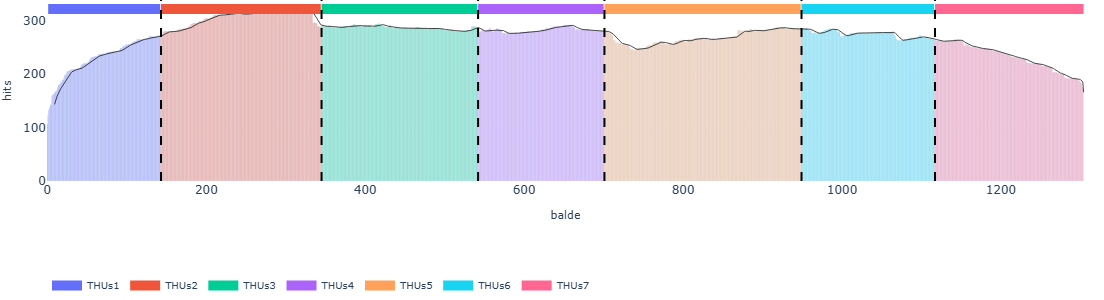

In [33]:
VIZ(mapping=mapping, windows=10, yname="hits", xname="balde", svgname="name", save=False)